# Machine Learning do marcador VIP

Este notebook analisa `ListagemCompleta (1).xlsx`, aprende os padrões históricos de **VIP / NÃO VIP** e produz um ranking operacional.

**Bibliotecas:** pandas, NumPy, scikit-learn, matplotlib, seaborn, openpyxl e joblib.

> O modelo mede semelhança com a marcação VIP histórica. Ele não mede valor pessoal nem conversão futura. Sexo, religião e idade são usados apenas em análises descritivas e não entram no treinamento.

## Como executar sem erros

Use **Executar tudo** e mantenha a ordem das células. Se o kernel for reiniciado, as variáveis `base`, `X`, `y` e `modelo` são apagadas e é necessário executar novamente desde o início. Não comece pelas seções 3 ou 7.

## 1. Instalação opcional

Execute a célula abaixo uma vez. O `%pip` instala as bibliotecas no mesmo kernel usado pelo notebook. Depois da instalação, reinicie o kernel se o VS Code solicitar.

In [1]:
%pip install --upgrade pandas numpy scikit-learn matplotlib seaborn openpyxl joblib jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl (15 kB)

   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import json
import re
import unicodedata

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
ARQUIVO = Path('ListagemCompleta (1).xlsx')
DATA_REFERENCIA = pd.Timestamp('2026-06-08')

## 2. Leitura e diagnóstico da base

In [3]:
df = pd.read_excel(ARQUIVO, engine='openpyxl')
print(f'Linhas: {len(df):,} | Colunas: {df.shape[1]}')
display(df.head())
display(df.dtypes.rename('tipo').to_frame())

c:\Users\Public\processamento-imagem\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Linhas: 45,964 | Colunas: 18


,ID,Aluno,Sobrenome,Cidade,Endereço,Bairro,Email,Telefone,Solicitação,Material,Religião,Idade,Sexo,Vip,Descrição,Distrito,Data de aniversário,Data do Último Contato
0,339,Antonio,Bezerra de Moura,OSASCO,"Rua RUA DA FRATERNIDADE, 457, - Jardim Orient...",Jardim Oriental,,+551185144341,11/09/2008,REVISTA VIVA COM ESPERANÇA - Impresso | 11/09/...,Assembléia de Deus,76,Masculino,Não,,Vila Yara,07/10/1949,11/09/2008
1,431,José,Raimundo dos Santos,ARAÇARIGUAMA,"Rua rua paraiba, 496, - Jardim Brasil - ARAÇA...",Jardim Brasil,,+551184954643,14/09/2008,PRINCÍPIOS - Impresso | 14/09/2008,,51,Masculino,Não,,Sao Roque,06/07/1974,14/09/2008
2,633,Regiane,de Souza,SÃO PAULO,"Rua Avenida Silvio Cerceline, 275, - Perdizes...",Perdizes,,,16/09/2008,PRINCÍPIOS - Impresso | 16/09/2008,,,Masculino,Não,Tentativa via Wpp em 13/05/26,Jardins,,16/09/2008
3,695,Margareth,Rogerio,SÃO PAULO,"Rua Rua João Álvares Soares, 1224, - CAMPO BE...",CAMPO BELO,,+551155427239,17/09/2008,PRINCÍPIOS - Impresso | 17/09/2008,Sem religião,65,Feminino,Não,,Brooklin,11/08/1960,17/09/2008
4,779,Ronaldo,Brayn,JANDIRA,"Rua Rua Satélite, 36, Casa 1 - VILA EUNICE - J...",VILA EUNICE,,,17/09/2008,REVISTA VIVA COM ESPERANÇA - Impresso | 17/09/...,Não Informado,,Masculino,Não,Tentativa via Wpp em 13/05/26,Jandira,,17/09/2008


,tipo
ID,int64
Aluno,str
Sobrenome,str
Cidade,str
Endereço,str
Bairro,str
Email,str
Telefone,str
Solicitação,str
Material,str


In [4]:
def normalizar_texto(valor):
    if pd.isna(valor):
        return 'NAO INFORMADO'
    texto = ' '.join(str(valor).strip().split())
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c)).upper() or 'NAO INFORMADO'

def quantidade_materiais(valor):
    if pd.isna(valor) or not str(valor).strip():
        return 0
    return len(re.split(r'\s*\*-\*\s*', str(valor).strip()))

def material_principal(valor):
    if pd.isna(valor) or not str(valor).strip():
        return 'NAO INFORMADO'
    primeiro = re.split(r'\s*\*-\*\s*', str(valor).strip())[0]
    nome = primeiro.split(' | ', 1)[0]
    nome = re.sub(r'\s*-\s*(IMPRESSO|PDF|DIGITAL)\s*$', '', nome, flags=re.I)
    return normalizar_texto(nome)

def telefone_valido(valor):
    digitos = re.sub(r'\D', '', '' if pd.isna(valor) else str(valor))
    return int(10 <= len(digitos) <= 13)

base = df.copy()
base['vip_alvo'] = base['Vip'].map(normalizar_texto).eq('SIM').astype(int)
base['ultimo_contato_dt'] = pd.to_datetime(base['Data do Último Contato'], dayfirst=True, errors='coerce')
base['dias_desde_contato'] = (DATA_REFERENCIA - base['ultimo_contato_dt']).dt.days.clip(lower=0)
base['log_dias_desde_contato'] = np.log1p(base['dias_desde_contato'].fillna(365 * 20))
base['materiais_quantidade'] = base['Material'].map(quantidade_materiais).clip(upper=20)
base['material_principal'] = base['Material'].map(material_principal)

for coluna in ['Cidade', 'Bairro', 'Distrito']:
    base[coluna.lower()] = base[coluna].map(normalizar_texto)

base['tem_telefone'] = base['Telefone'].fillna('').astype(str).str.strip().ne('').astype(int)
base['telefone_valido'] = base['Telefone'].map(telefone_valido)
base['tem_email'] = base['Email'].fillna('').astype(str).str.strip().ne('').astype(int)
base['email_valido'] = base['Email'].fillna('').astype(str).str.match(r'^[^@\s]+@[^@\s]+\.[^@\s]+$').astype(int)
base['tem_descricao'] = base['Descrição'].fillna('').astype(str).str.strip().ne('').astype(int)

display(base[['vip_alvo', 'ultimo_contato_dt', 'materiais_quantidade', 'material_principal']].head())

,vip_alvo,ultimo_contato_dt,materiais_quantidade,material_principal
0,0,2008-09-11,2,REVISTA VIVA COM ESPERANCA
1,0,2008-09-14,1,PRINCIPIOS
2,0,2008-09-16,1,PRINCIPIOS
3,0,2008-09-17,1,PRINCIPIOS
4,0,2008-09-17,2,REVISTA VIVA COM ESPERANCA


## 3. Exploração visual

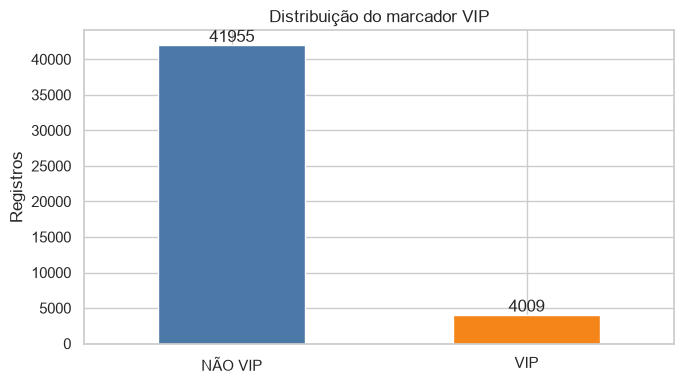

Taxa VIP: 8.7%


In [5]:
resumo_vip = base['vip_alvo'].value_counts().rename(index={0: 'NÃO VIP', 1: 'VIP'})
ax = resumo_vip.plot(kind='bar', color=['#4C78A8', '#F58518'], figsize=(7, 4))
ax.set(title='Distribuição do marcador VIP', xlabel='', ylabel='Registros')
ax.bar_label(ax.containers[0], fmt='%.0f')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Taxa VIP: {base.vip_alvo.mean():.1%}')

,registros,materiais_mediana,dias_mediana,telefone,email,descricao
vip_alvo,,,,,,
NÃO VIP,41955,1.0,2153.0,94.6%,91.7%,6.3%
VIP,4009,3.0,2881.0,62.9%,97.7%,38.4%


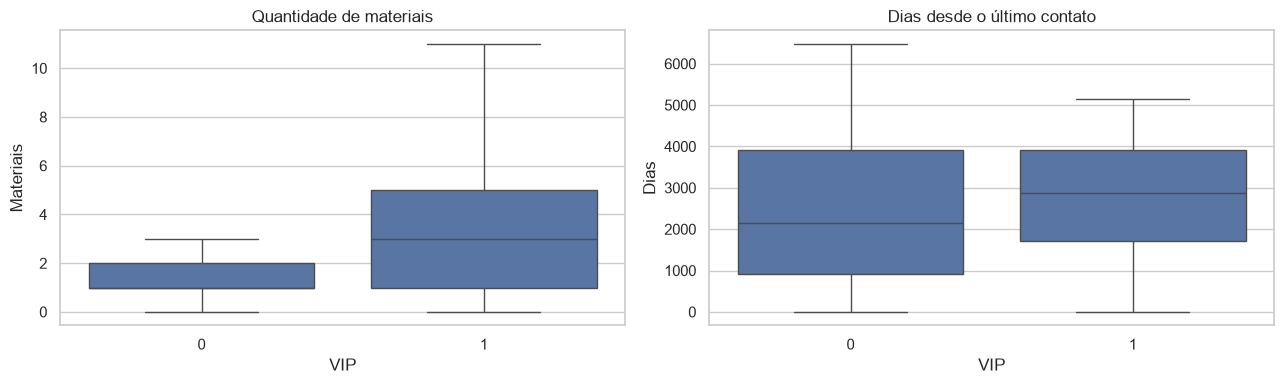

In [6]:
if 'base' not in globals():
    raise RuntimeError('A base ainda não foi preparada. Execute todas as células das seções 1 e 2 antes desta célula.')

comparacao = (
    base.groupby('vip_alvo')
        .agg(
            registros=('vip_alvo', 'size'),
            materiais_mediana=('materiais_quantidade', 'median'),
            dias_mediana=('dias_desde_contato', 'median'),
            telefone=('tem_telefone', 'mean'),
            email=('tem_email', 'mean'),
            descricao=('tem_descricao', 'mean'),
        )
        .rename(index={0: 'NÃO VIP', 1: 'VIP'})
)
comparacao_exibicao = comparacao.copy()
for coluna in ['telefone', 'email', 'descricao']:
    comparacao_exibicao[coluna] = comparacao_exibicao[coluna].map(lambda valor: f'{valor:.1%}')
display(comparacao_exibicao)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=base, x='vip_alvo', y='materiais_quantidade', showfliers=False, ax=axes[0])
axes[0].set(title='Quantidade de materiais', xlabel='VIP', ylabel='Materiais')
sns.boxplot(data=base, x='vip_alvo', y='dias_desde_contato', showfliers=False, ax=axes[1])
axes[1].set(title='Dias desde o último contato', xlabel='VIP', ylabel='Dias')
plt.tight_layout()
plt.show()

,total,vips,taxa_vip
distrito,,,
PINHEIROS,914,108,11.8%
VARGEM GRANDE,43,5,11.6%
CLINICA,130,15,11.5%
JARDIM DA GRACA,241,27,11.2%
JARDIM COLONIAL,410,45,11.0%
BROOKLIN,806,88,10.9%
VILA RODRIGUES,811,86,10.6%
JARDIM BELA VISTA,400,42,10.5%
JARDIM SILVEIRA,263,27,10.3%


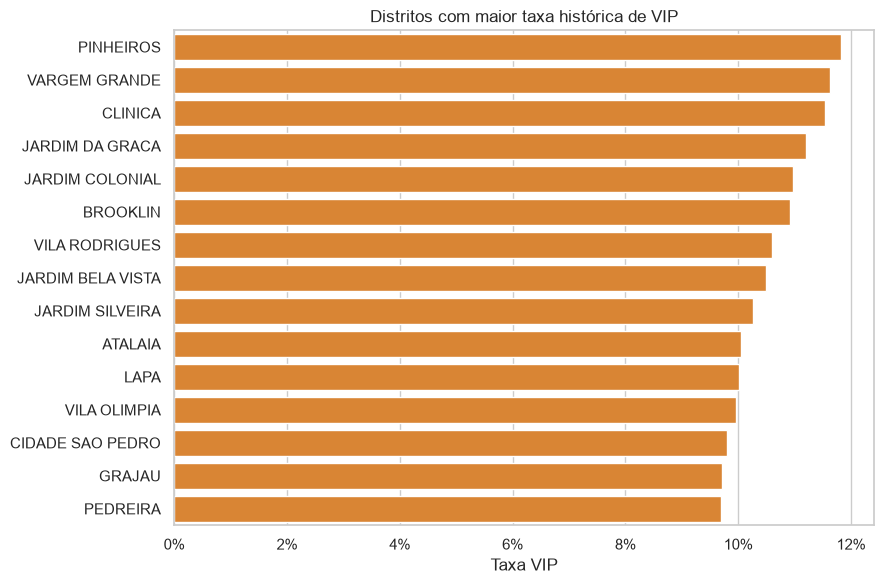

In [7]:
if 'base' not in globals():
    raise RuntimeError('A base ainda não foi preparada. Execute todas as células das seções 1 e 2 antes desta célula.')

def taxas_por_grupo(coluna, minimo=30, limite=15):
    tabela = base.groupby(coluna)['vip_alvo'].agg(['size', 'sum', 'mean'])
    tabela = tabela[tabela['size'] >= minimo].nlargest(limite, 'mean')
    return tabela.rename(columns={'size': 'total', 'sum': 'vips', 'mean': 'taxa_vip'})

taxas_distrito = taxas_por_grupo('distrito')
taxas_distrito_exibicao = taxas_distrito.copy()
taxas_distrito_exibicao['taxa_vip'] = taxas_distrito_exibicao['taxa_vip'].map(lambda valor: f'{valor:.1%}')
display(taxas_distrito_exibicao)

plt.figure(figsize=(9, 6))
sns.barplot(data=taxas_distrito.reset_index(), y='distrito', x='taxa_vip', color='#F58518')
plt.title('Distritos com maior taxa histórica de VIP')
plt.xlabel('Taxa VIP')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
plt.tight_layout()
plt.show()

## 4. Preparação e treinamento

O modelo utiliza apenas atributos operacionais. Categorias desconhecidas são ignoradas pelo `OneHotEncoder`.

In [8]:
if 'base' not in globals():
    raise RuntimeError('A base ainda não foi preparada. Execute todas as células das seções 1 e 2 antes de treinar.')

numericas = [
    'log_dias_desde_contato', 'materiais_quantidade', 'tem_telefone',
    'telefone_valido', 'tem_email', 'email_valido', 'tem_descricao'
]
categoricas = ['cidade', 'bairro', 'distrito', 'material_principal']
atributos = numericas + categoricas

X = base[atributos]
y = base['vip_alvo']
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

pipeline_numerico = Pipeline([
    ('imputacao', SimpleImputer(strategy='median')),
    ('escala', StandardScaler()),
])
pipeline_categorico = Pipeline([
    ('imputacao', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=20)),
])
preprocessador = ColumnTransformer([
    ('numericas', pipeline_numerico, numericas),
    ('categoricas', pipeline_categorico, categoricas),
])
modelo = Pipeline([
    ('preprocessamento', preprocessador),
    ('classificador', LogisticRegression(
        class_weight='balanced', max_iter=1500, C=0.8, solver='liblinear', random_state=RANDOM_STATE
    )),
])

modelo.fit(X_treino, y_treino)
prob_teste = modelo.predict_proba(X_teste)[:, 1]
pred_teste = modelo.predict(X_teste)
print('ROC AUC:', round(roc_auc_score(y_teste, prob_teste), 4))
print('Average Precision:', round(average_precision_score(y_teste, prob_teste), 4))
print(classification_report(y_teste, pred_teste, target_names=['NÃO VIP', 'VIP']))

ROC AUC: 0.9581
Average Precision: 0.748
              precision    recall  f1-score   support

     NÃO VIP       0.99      0.93      0.96      8391
         VIP       0.53      0.87      0.66       802

    accuracy                           0.92      9193
   macro avg       0.76      0.90      0.81      9193
weighted avg       0.95      0.92      0.93      9193



## 5. Avaliação gráfica

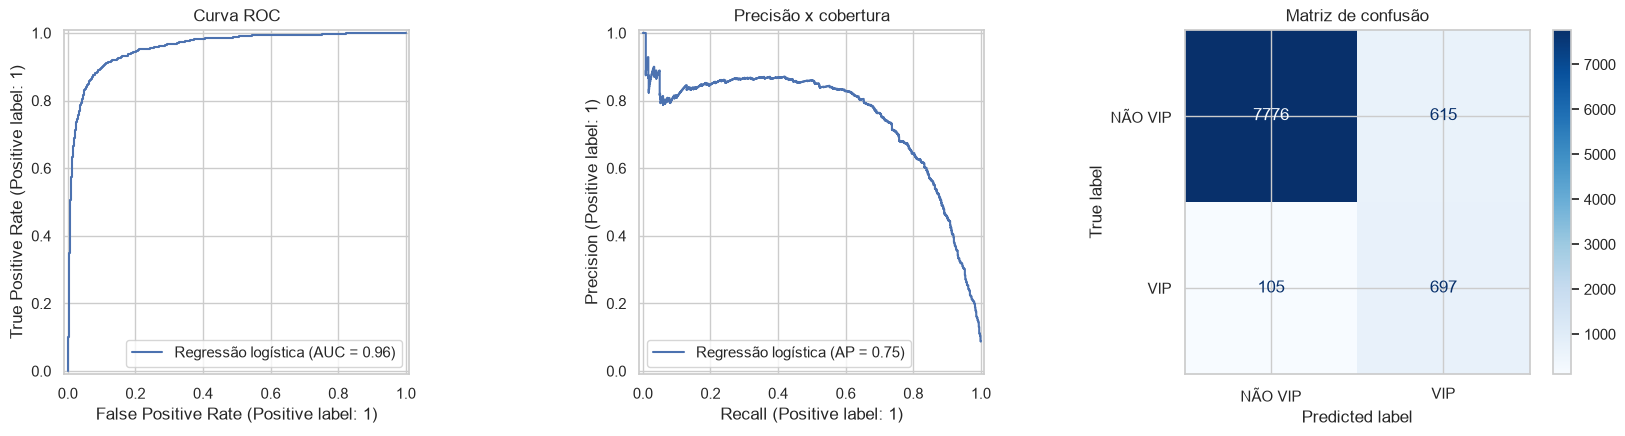

In [9]:
if not {'y_teste', 'prob_teste', 'pred_teste'}.issubset(globals()):
    raise RuntimeError('O modelo ainda não foi avaliado. Execute primeiro toda a seção 4.')

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
RocCurveDisplay.from_predictions(y_teste, prob_teste, ax=axes[0], name='Regressão logística')
PrecisionRecallDisplay.from_predictions(y_teste, prob_teste, ax=axes[1], name='Regressão logística')
ConfusionMatrixDisplay.from_predictions(y_teste, pred_teste, ax=axes[2], display_labels=['NÃO VIP', 'VIP'], cmap='Blues')
axes[0].set_title('Curva ROC')
axes[1].set_title('Precisão x cobertura')
axes[2].set_title('Matriz de confusão')
plt.tight_layout()
plt.show()

## 6. Interpretação dos fatores

Coeficientes positivos indicam associação com VIP histórico; negativos indicam associação com NÃO VIP. Isso não implica causalidade.

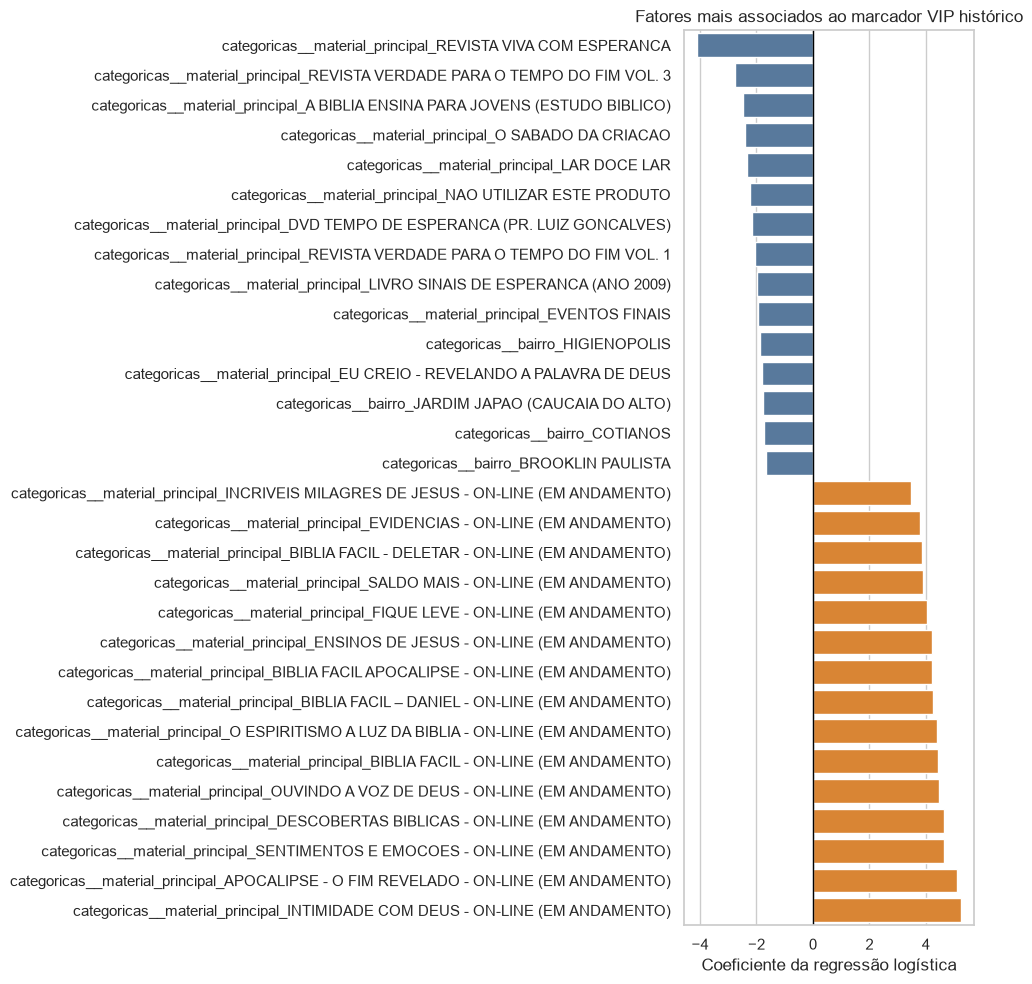

,atributo,coeficiente
576,categoricas__material_principal_INTIMIDADE COM...,5.238357
534,categoricas__material_principal_APOCALIPSE - O...,5.103334
609,categoricas__material_principal_SENTIMENTOS E ...,4.639604
552,categoricas__material_principal_DESCOBERTAS BI...,4.626924
595,categoricas__material_principal_OUVINDO A VOZ ...,4.465291
540,categoricas__material_principal_BIBLIA FACIL -...,4.440118
590,categoricas__material_principal_O ESPIRITISMO ...,4.406041
543,categoricas__material_principal_BIBLIA FACIL –...,4.236432
542,categoricas__material_principal_BIBLIA FACIL A...,4.214798
561,categoricas__material_principal_ENSINOS DE JES...,4.210220


,atributo,coeficiente
603,categoricas__material_principal_REVISTA VIVA C...,-4.098443
602,categoricas__material_principal_REVISTA VERDAD...,-2.748772
524,categoricas__material_principal_A BIBLIA ENSIN...,-2.491601
593,categoricas__material_principal_O SABADO DA CR...,-2.410134
578,categoricas__material_principal_LAR DOCE LAR,-2.338814
588,categoricas__material_principal_NAO UTILIZAR E...,-2.245942
558,categoricas__material_principal_DVD TEMPO DE E...,-2.163598
601,categoricas__material_principal_REVISTA VERDAD...,-2.040317
582,categoricas__material_principal_LIVRO SINAIS D...,-1.989488
567,categoricas__material_principal_EVENTOS FINAIS,-1.938043


In [10]:
if 'modelo' not in globals():
    raise RuntimeError('O modelo ainda não foi treinado. Execute primeiro toda a seção 4.')

nomes_atributos = modelo.named_steps['preprocessamento'].get_feature_names_out()
coeficientes = modelo.named_steps['classificador'].coef_[0]
importancias = pd.DataFrame({'atributo': nomes_atributos, 'coeficiente': coeficientes})
extremos = pd.concat([
    importancias.nsmallest(15, 'coeficiente'),
    importancias.nlargest(15, 'coeficiente'),
]).drop_duplicates().sort_values('coeficiente')

plt.figure(figsize=(10, 10))
sns.barplot(data=extremos, y='atributo', x='coeficiente', hue=extremos['coeficiente'].gt(0), palette={True: '#F58518', False: '#4C78A8'}, legend=False)
plt.axvline(0, color='black', linewidth=1)
plt.title('Fatores mais associados ao marcador VIP histórico')
plt.xlabel('Coeficiente da regressão logística')
plt.ylabel('')
plt.tight_layout()
plt.show()
display(importancias.nlargest(15, 'coeficiente'))
display(importancias.nsmallest(15, 'coeficiente'))

## 7. Score de prioridade operacional

A prioridade combina:

- 40% do percentil de similaridade com VIP;
- 40% de recência, com decaimento em três anos;
- 20% de contactabilidade.

Assim, um registro antigo não fica no topo apenas por se parecer com VIPs históricos.

In [11]:
# Esta etapa depende da seção 4 (Preparação e treinamento).
variaveis_necessarias = ['modelo', 'X', 'y', 'base']
variaveis_ausentes = [nome for nome in variaveis_necessarias if nome not in globals()]
if variaveis_ausentes:
    raise RuntimeError(
        'Execute primeiro todas as células até a seção 4. Variáveis ausentes: '
        + ', '.join(variaveis_ausentes)
    )

# Reajuste final com toda a base para gerar o ranking operacional.
modelo_final = modelo.fit(X, y)
base['score_similaridade_vip'] = modelo_final.predict_proba(X)[:, 1]

nao_vip = base['vip_alvo'].eq(0)
base['percentil_similaridade'] = 1.0
base.loc[nao_vip, 'percentil_similaridade'] = base.loc[nao_vip, 'score_similaridade_vip'].rank(pct=True)
base['score_recencia'] = np.exp(-base['dias_desde_contato'].fillna(365 * 20) / (365 * 3))
base['score_contato'] = (
    0.55 * base['telefone_valido'] +
    0.30 * base['email_valido'] +
    0.10 * base['tem_telefone'] +
    0.05 * base['tem_email']
).clip(upper=1)
base['score_prioridade_operacional'] = (
    0.40 * base['percentil_similaridade'] +
    0.40 * base['score_recencia'] +
    0.20 * base['score_contato']
)
base['faixa_prioridade'] = pd.cut(
    base['score_prioridade_operacional'],
    bins=[-np.inf, 0.45, 0.70, np.inf],
    labels=['baixa', 'media', 'alta'],
    right=False,
)

ranking = base.loc[nao_vip].sort_values('score_prioridade_operacional', ascending=False).copy()
ranking['nome'] = (ranking['Aluno'].fillna('') + ' ' + ranking['Sobrenome'].fillna('')).str.strip()
colunas_saida = [
    'ID', 'nome', 'Distrito', 'Cidade', 'Bairro', 'Telefone', 'Email',
    'Data do Último Contato', 'Vip', 'score_similaridade_vip',
    'score_prioridade_operacional', 'faixa_prioridade'
]
display(ranking[colunas_saida].head(20))

,ID,nome,Distrito,Cidade,Bairro,Telefone,Email,Data do Último Contato,Vip,score_similaridade_vip,score_prioridade_operacional,faixa_prioridade
32983,2570718,Maria Bela Da Cruz,Jardim Três Corações,SÃO PAULO,Jardim Novo Horizonte,+55(11)950631568,mariabelalima.60@gmail.com,06/06/2026,Não,0.999419,0.998412,alta
41542,3332138,Almir Jorge Dornelles,Mirandopolis,SÃO PAULO,Mirandópolis,+55(11)947234279,dornellescorretor1962@gmail.com,31/05/2026,Não,0.999708,0.996373,alta
33469,2609923,José Gomes de Lima,Jardim Três Corações,SÃO PAULO,Jardim Novo Horizonte,+55(11)50631568,mariabelalima.60@gmail.com,04/06/2026,Não,0.983096,0.995462,alta
39421,3136778,Tânia Regina Somenek Bonachelo,Jardim Helena Maria,BARUERI,Jardim Santa Cecília,+55(11)973952972,taniabonanek@gmail.com,25/05/2026,Não,0.998628,0.993803,alta
35390,2738988,Ramon Tavares Correia da Silva,Pilar Do Sul,PILAR DO SUL,Parque Residencial Campestre I,+55(19)983363278,ramontavaressilva22@gmail.com,19/05/2026,Não,0.998929,0.991712,alta
38857,3070860,Cristiano Lins Teixeira,Jardim Três Corações,SÃO PAULO,Jardim Guanabara,+55(11)996649933,cristianooito@gmail.com,21/05/2026,Não,0.995028,0.991562,alta
5463,685672,Maria Ivani Do Couto,Vila Yara,SÃO PAULO,Jaguaré,+55(11)972235013,ivanicouto@yahoo.com.br,18/05/2026,Não,0.996688,0.990829,alta
31673,2456058,Aline Morais Gomes,Jardim Gaivotas,SÃO PAULO,Cantinho Do Céu,+55(11)955527909,alinemoraisgomes5528@gmail.com,18/05/2026,Não,0.974804,0.988626,alta
25060,1958107,Priscila Damasceno,Carapicuiba,CARAPICUÍBA,Jardim Maria Beatriz,+55(11)976753032,pri.dama0710@gmail.com,27/05/2026,Não,0.850992,0.986631,alta
40259,3202336,Iractan Marcos Gomes,Campo Grande,SÃO PAULO,Jardim Dos Prados,+55(11)947499542,iractan@yahoo.com.br,13/05/2026,Não,0.960842,0.985885,alta


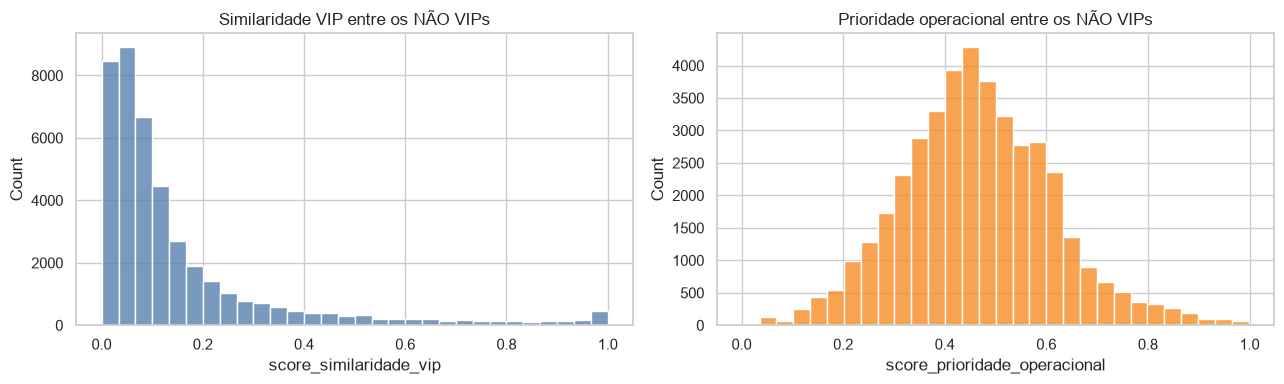

,quantidade
faixa_prioridade,
baixa,20058
media,19320
alta,2577


In [12]:
if 'ranking' not in globals():
    raise RuntimeError('O ranking ainda não foi calculado. Execute primeiro a célula anterior da seção 7.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=ranking, x='score_similaridade_vip', bins=30, ax=axes[0], color='#4C78A8')
axes[0].set_title('Similaridade VIP entre os NÃO VIPs')
sns.histplot(data=ranking, x='score_prioridade_operacional', bins=30, ax=axes[1], color='#F58518')
axes[1].set_title('Prioridade operacional entre os NÃO VIPs')
plt.tight_layout()
plt.show()

display(ranking['faixa_prioridade'].value_counts().to_frame('quantidade'))

## 8. Alphaville

NÃO VIPs em Alphaville: 138


,ID,nome,Distrito,Cidade,Bairro,Telefone,Email,Data do Último Contato,Vip,score_similaridade_vip,score_prioridade_operacional,faixa_prioridade
42985,3499136,Viviane Magalhães Palma Fernandes,Alphaville,BARUERI,Alphaville Empresarial,+55(19)974250770,pavipa2008@hotmail.com,11/02/2026,Não,0.024095,0.611396,media
7609,848806,Bianka Beatriz Straub Alcantara,Alphaville,BARUERI,Alphaville Empresarial,+55(41)99309341,biankaalcantara.psicologia@gmail.com; biaqq2@h...,19/12/2024,Não,0.092368,0.601310,media
45635,3763801,Weslley Rodrigues,Alphaville,BARUERI,Alphaville Empresarial,+55(11)974730534,weslley.lourenco@outlook.com,05/06/2026,Não,0.002264,0.599764,media
3371,464522,Eleny De Almeida Sobreda,Alphaville,BARUERI,Alphaville Industrial,+55(11)78784181,sobreda9@hotmail.com,27/08/2018,Não,0.440601,0.597630,media
4282,541357,JULIO CESAR FELIPE,Alphaville,BARUERI,Alphaville Industrial,+551142088000,julio.felipe@tempoassist.com.br,05/05/2012,Não,0.880082,0.595504,media
33032,2574904,Flavia Caroline da Silva,Alphaville,BARUERI,Alphaville Empresarial,+55(11)993350252,flavia_csilva@outlook.com,18/10/2024,Não,0.064941,0.592745,media
24600,1921299,Daniel Olivieri Reis,Alphaville,BARUERI,Alphaville Industrial,+55(11)963153516,daniel.olivieri.reis@gmail.com,17/10/2021,Não,0.184229,0.592622,media
44782,3704014,Michelle Balestero,Alphaville,BARUERI,Alphaville Empresarial,+55(11)952817800,mibchelle@gmail.com,01/04/2026,Não,0.010940,0.592257,media
35589,2754115,Carlos Barreto Ramos Junior,Alphaville,BARUERI,Alphaville Industrial,+55(11)992087461,carlosbarretojr@uol.com.br,02/03/2023,Não,0.120111,0.591087,media
39881,3169929,Leandro de Sousa Medeiros,Alphaville,BARUERI,Alphaville Industrial,+55(11)964323595,sousa.leandro62@gmail.com,12/06/2024,Não,0.074728,0.588771,media


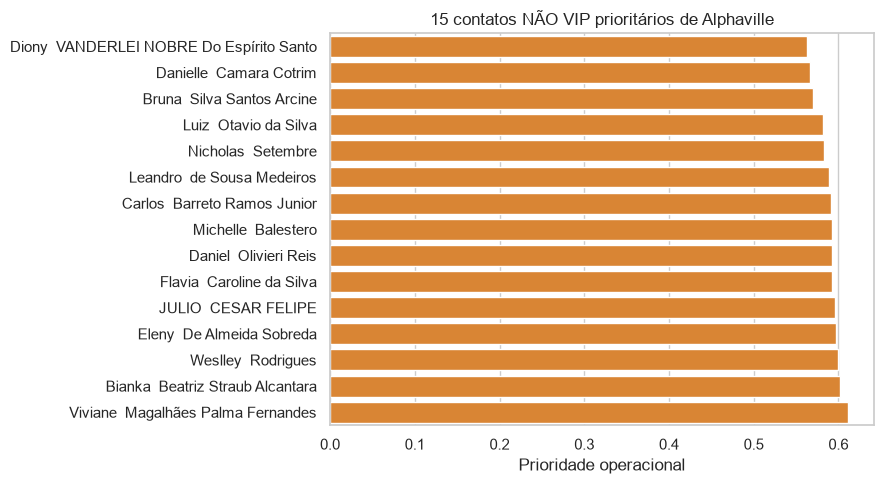

In [13]:
if 'ranking' not in globals():
    raise RuntimeError('O ranking geral ainda não foi calculado. Execute primeiro toda a seção 7.')

ranking_alphaville = ranking[ranking['distrito'].eq('ALPHAVILLE')].copy()
print(f'NÃO VIPs em Alphaville: {len(ranking_alphaville)}')
display(ranking_alphaville[colunas_saida].head(30))

plt.figure(figsize=(9, 5))
top_alphaville = ranking_alphaville.head(15).sort_values('score_prioridade_operacional')
sns.barplot(data=top_alphaville, y='nome', x='score_prioridade_operacional', color='#F58518')
plt.title('15 contatos NÃO VIP prioritários de Alphaville')
plt.xlabel('Prioridade operacional')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 9. Exportação

In [14]:
if not {'ranking', 'ranking_alphaville', 'modelo_final'}.issubset(globals()):
    raise RuntimeError('Os resultados ainda não estão prontos. Execute todas as células anteriores antes da exportação.')

ranking[colunas_saida].to_csv('ranking_nao_vip_ml_pandas.csv', index=False, encoding='utf-8-sig')
ranking_alphaville[colunas_saida].to_csv('ranking_Alphaville_ml_pandas.csv', index=False, encoding='utf-8-sig')
joblib.dump(modelo_final, 'modelo_vip_sklearn.joblib')

metricas = {
    'registros': int(len(base)),
    'vips': int(base['vip_alvo'].sum()),
    'taxa_vip': float(base['vip_alvo'].mean()),
    'roc_auc_teste': float(roc_auc_score(y_teste, prob_teste)),
    'average_precision_teste': float(average_precision_score(y_teste, prob_teste)),
    'random_state': RANDOM_STATE,
    'bibliotecas': ['pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'openpyxl', 'joblib'],
}
Path('metricas_vip_sklearn.json').write_text(json.dumps(metricas, indent=2, ensure_ascii=False), encoding='utf-8')

print('Arquivos gerados:')
print('- ranking_nao_vip_ml_pandas.csv')
print('- ranking_Alphaville_ml_pandas.csv')
print('- modelo_vip_sklearn.joblib')
print('- metricas_vip_sklearn.json')

Arquivos gerados:
- ranking_nao_vip_ml_pandas.csv
- ranking_Alphaville_ml_pandas.csv
- modelo_vip_sklearn.joblib
- metricas_vip_sklearn.json


## Conclusão

O campo VIP é útil como registro histórico, mas não deve ser confundido com prioridade atual. O modelo serve para auditar esse rótulo; o score operacional acrescenta recência e possibilidade real de contato para apoiar a abordagem.